# Canonical Model 02 · Visual Diagnostics

The canonical forcing is deliberately **visible**: a regional down-valley
gradient, a high-K paleochannel, a cross-valley low-K constriction, gaining and
losing stream reaches, a perched lake, an **infiltration** mound, and pumping
cones. Each plot below is rendered in **both** backends — static `matplotlib`
and interactive `plotly` — so the same diagnostic works in a report and on screen.

> **Visual standard:** a plot should reveal a decision-relevant feature, not
> merely prove that plotting code runs.

In [1]:
import sys
from pathlib import Path

# Make the in-repo `src/` importable when myflopy is not pip-installed.
src = Path.cwd().parents[2] / 'src'
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))
import myflopy as mf
from canonical_notebook_style import notebook_header

notebook_header('02', 'Visual Diagnostics', 'See gradients, the paleochannel, gaining/losing streams, the perched lake, and pumping.')

root = Path('../artifacts/canonical_visuals')
config = mf.CanonicalModelConfig.validation()
model = mf.build_canonical_model(root / 'gwf', config=config)
assert model.run_simulation()[0]

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from myflopy.modflow.mf6.grid.plotting import build_choropleth

def head_layer(model, layer=0, per=-1):
    """Return the simulated head for one layer at one stress period (1-D, per cell)."""
    reader = model.gwf.output.head()
    arr = np.asarray(reader.get_data(kstpkper=reader.get_kstpkper()[per]), float)
    arr = arr.reshape(model.gwf.modelgrid.nlay, model.gwf.modelgrid.ncpl)
    arr[np.abs(arr) > 1e29] = np.nan
    return arr[layer]

def cell_map(model, values, *, title='', cmap='viridis', ax=None, vmin=None, vmax=None,
             outline=('all_streams', 'all_lakes')):
    """Static matplotlib choropleth of a per-cell array on the Voronoi grid.

    Surface-water regions are outlined in black for context.
    """
    gdf = model.vor.gdf_vorPolys.copy()
    gdf['value'] = np.asarray(values, float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    gdf.plot(column='value', ax=ax, cmap=cmap, legend=True, vmin=vmin, vmax=vmax)
    for name in outline:
        cells = list(model.get_region_cells(name))
        if cells:
            gdf.iloc[cells].boundary.plot(ax=ax, color='black', linewidth=0.5)
    ax.set_aspect('equal'); ax.set_axis_off(); ax.set_title(title)
    return ax.figure


VoronoiGrid initializing.
Voronoi grid initialized.


getting connectivity properties (iac, ja, cl12, hwva, nja)


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model viz_prt_master...
    writing model name file...
    writing package disv...
    writing package ic...


    writing package npf...
    writing package sto...
    writing package chd...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 200 based on size of stress_period_data
    writing package ghb...
INFORMATION: maxbound in ('', 'ghb', 'dimensions') changed to 200 based on size of stress_period_data
    writing package rch...


...

    Solving:  Stress period:     5    Time step:     1


    Solving:  Stress period:     5    Time step:     2


    Solving:  Stress period:     6    Time step:     1


    Solving:  Stress period:     6    Time step:     2


 
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2026/06/22 21:49:43
 Elapsed run time:  6.562 Seconds
 
 Normal termination of simulation.

Success is:  True


## 1 · Water table and regional gradient

**What to look for:** a strong head decline from the up-valley head toward the
valley mouth (left to right), bent by the high-K paleochannel along the axis and
tightened at the mid-valley constriction. The stream and lake outlines mark where
surface water interacts with this water table.

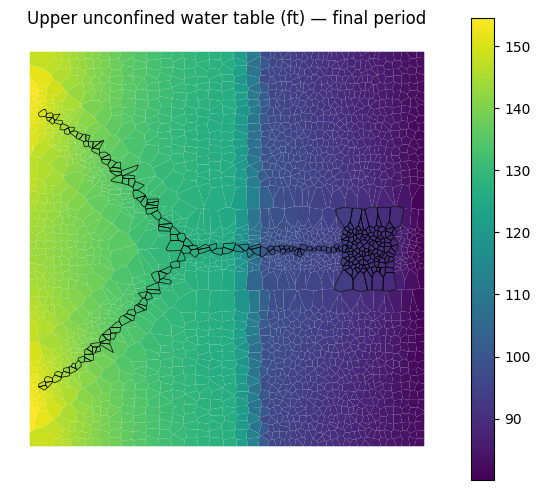

In [2]:
wt = head_layer(model, layer=0, per=-1)
cell_map(model, wt, title='Upper unconfined water table (ft) — final period',
         cmap='viridis')
# Interactive plotly choropleth (same array):
build_choropleth(model.vor, custom_zs=list(wt), layer=0).plot()

## 2 · Vertical structure (four-layer head mosaic)

**What to look for:** the two unconfined layers track each other; the head field
changes character across the **aquitard** (layer 3) into the **confined** aquifer
(layer 4), where the deep pumping cone is most distinct. This is the visual proof
the low-K aquitard damps vertical communication.

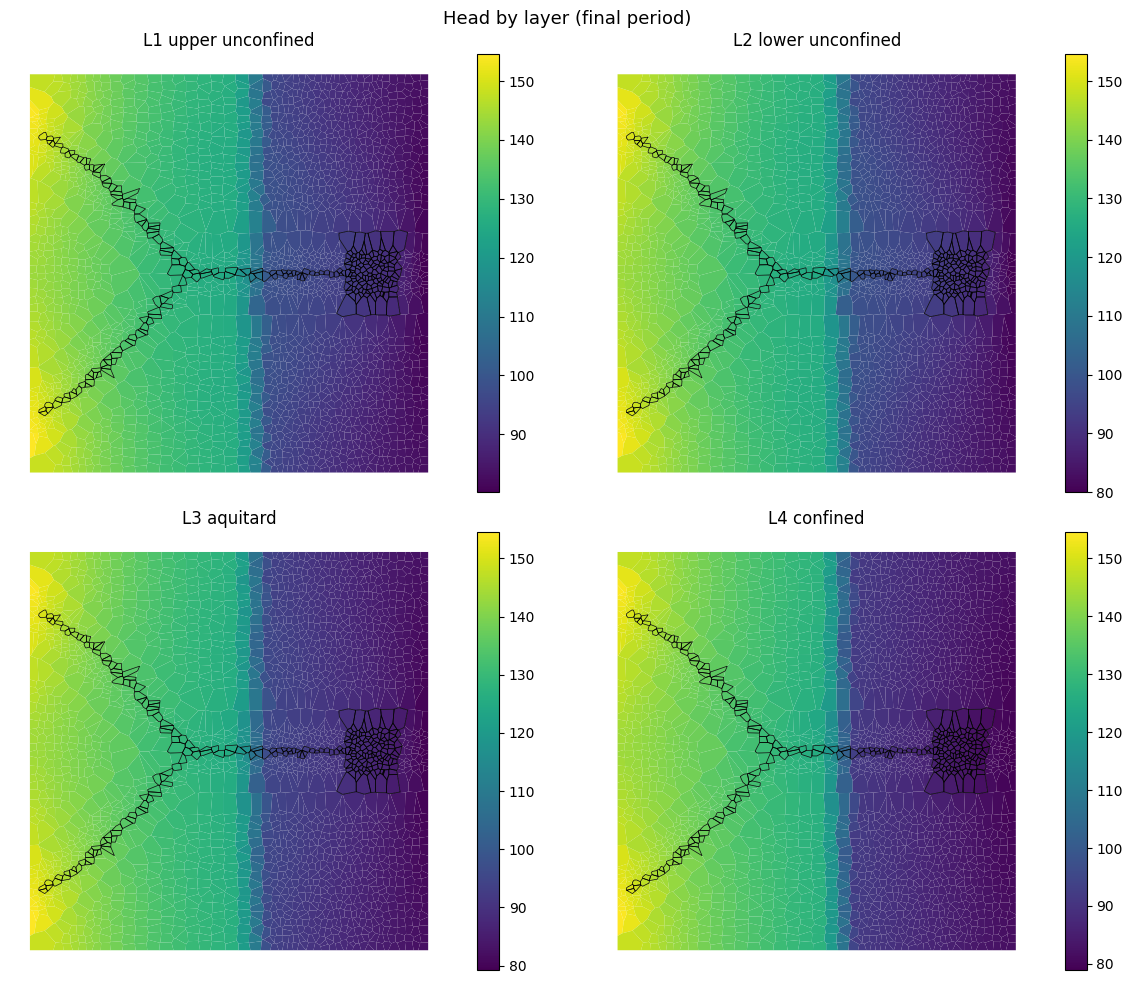

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
roles = ['L1 upper unconfined', 'L2 lower unconfined', 'L3 aquitard', 'L4 confined']
for layer, (ax, role) in enumerate(zip(axes.ravel(), roles)):
    cell_map(model, head_layer(model, layer=layer, per=-1), title=role, ax=ax)
fig.suptitle('Head by layer (final period)', fontsize=13)
fig.tight_layout()

## 3 · Gaining vs. losing streams

The SFR network is a resolved, continuously wet stream, not a decorative line.
**What to look for:** stage held just above the streambed along the whole channel,
and the stream→aquifer exchange flipping sign — **negative (gaining)** where the
stream sits below the water table in the headwaters, turning **positive (losing)**
downgradient toward the perched lake.

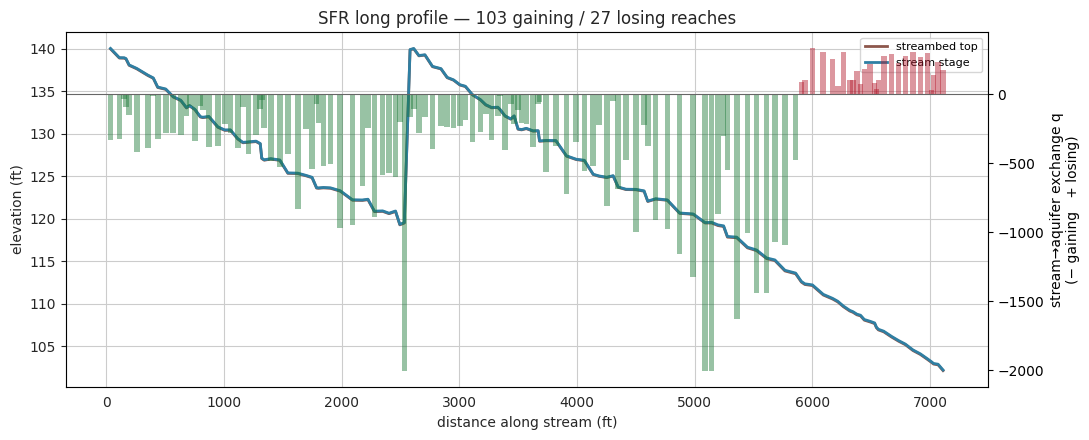

In [4]:
per = config.nper - 1
prof = model.packages.sfr.results.long_profile(per=per).sort_values('distance_mid')
q = prof['q'].to_numpy(float)

with sns.axes_style('whitegrid'):
    fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(prof['distance_mid'], prof['streambed_top'], color='#8c564b', lw=2, label='streambed top')
ax.plot(prof['distance_mid'], prof['stage'], color='#2f7fa3', lw=2, label='stream stage')
ax.set_xlabel('distance along stream (ft)'); ax.set_ylabel('elevation (ft)')
ax.legend(loc='upper right', fontsize=8)
ax2 = ax.twinx()
width = float(np.median(np.diff(prof['distance_mid']))) * 0.9
colors = np.where(q < 0, '#1b7837', '#b2182b')   # gaining green, losing red
ax2.bar(prof['distance_mid'], q, width=width, color=colors, alpha=0.45)
ax2.axhline(0, color='0.4', lw=0.8)
ax2.set_ylabel('stream→aquifer exchange q\n(− gaining   + losing)')
ax.set_title(f'SFR long profile — {int((q<0).sum())} gaining / {int((q>0).sum())} losing reaches')
fig.tight_layout()
# Interactive long profile (stage, streambed, exchange on a secondary axis):
model.packages.sfr.results.plot_long_profile(per=per, plot_fig=True)

## 4 · The perched lake and its budget

The terminal lake receives the main stem's routed flow (via MVR) and sits above
the downgradient water table. **What to look for:** the lake-aquifer exchange is
**negative** — the perched lake **loses** water downward to the aquifer through
its bed (both horizontal and vertical connections), rather than the aquifer
feeding the lake.

,per,lake,claktype,record_count,q,flow_area,q_per_area
0,5,0,HORIZONTAL,142,-29163.356907,39810.264587,-0.732559
1,5,0,VERTICAL,260,-59684.903781,527698.391550,-0.113104


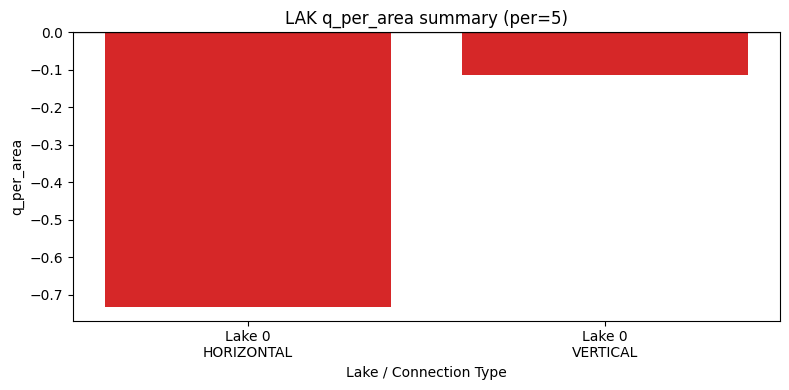

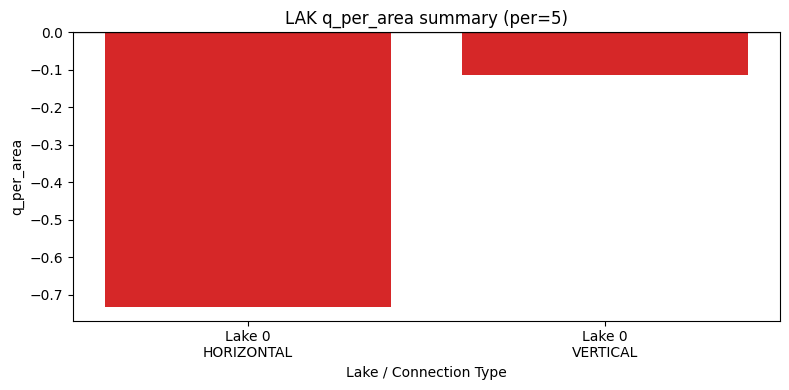

In [5]:
display(model.packages.lak.results.q.budget_summary(per=per))
# Signed exchange by connection type for this period (matplotlib):
model.packages.lak.results.q.plot_budget(per=per)

## 5 · Hydraulic conductivity — the paleochannel

**What to look for:** a high-K ribbon (the buried **paleochannel**) running down
the valley axis that channels flow toward the streams and lake, pinched by the
low-K cross-valley **constriction** near mid-valley. This is the heterogeneity the
PEST notebooks (04–06) try to recover from heads alone.

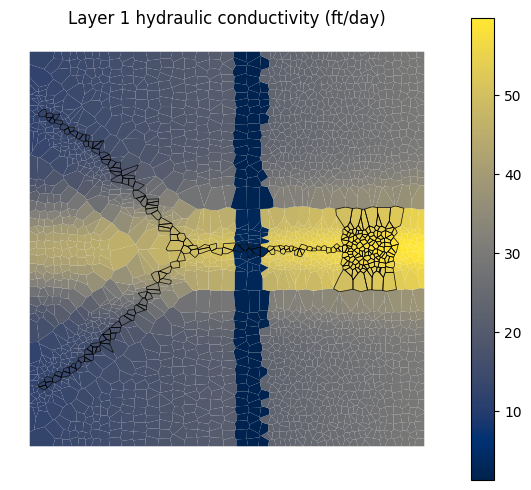

In [6]:
k0 = np.asarray(model.gwf.npf.k.get_data(), float)[0]
cell_map(model, k0, title='Layer 1 hydraulic conductivity (ft/day)', cmap='cividis')
build_choropleth(model.vor, custom_zs=list(k0), layer=0).plot()

## 6 · Pumping drawdown

**What to look for:** a localized cone of depression in the lower unconfined
aquifer (layer 2) around the shallow well, where head has dropped from the start
of the simulation to the end. The confined well (layer 4) produces a separate,
broader cone beneath the aquitard.

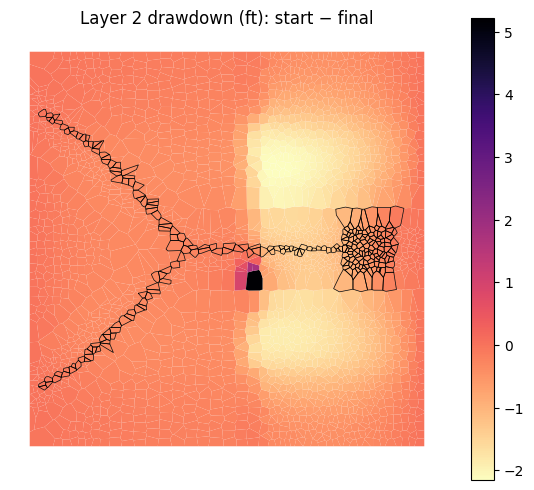

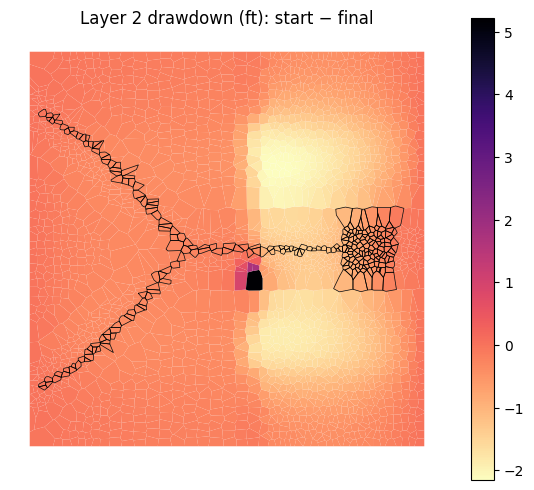

In [7]:
drawdown = head_layer(model, layer=1, per=0) - head_layer(model, layer=1, per=-1)
cell_map(model, drawdown, title='Layer 2 drawdown (ft): start − final', cmap='magma_r')

## Interpretation checklist

- Contours bend along the paleochannel and tighten at the constriction.
- The stream is gaining in the headwaters and losing toward the lake.
- The perched lake leaks downward (negative exchange).
- The aquitard damps vertical propagation between the unconfined and confined layers.
- Each pumping well shows a localized drawdown cone.

Continue to **03 · PRT and Parallel** to test movement and computational scaling.